In [1]:
import json

import tiktoken

import pandas as pd
from datasets import load_dataset
from transformers import PreTrainedTokenizerFast
dataset = load_dataset(
    "parquet",
    data_files='../local_datasets/8needle_1.parquet'
)['train']

# deepseek 分词器
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    "deepseek-ai/DeepSeek-V3.2-Exp"
)

# openai 分词器
enc = tiktoken.get_encoding("o200k_base")


/Users/zeng/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
def oai_n_tokens_messages_only(messages : list[dict]) -> int:
    """
    Count tokens in messages.
    """
    return sum([len(enc.encode(m["content"])) for m in messages])

In [5]:
dataset_df = dataset.to_pandas()

In [12]:
# dataset_df['prompt_tokens_len'] = dataset_df['prompt'].apply(lambda x: len(tokenizer(x)))
dataset_df['n_chars'] = dataset_df['n_chars'].astype(int)
dataset_df_128k = dataset_df[(dataset_df["n_chars"] >= 100000*5) & (dataset_df["n_chars"] < 140000*5)].sort_values(by='n_chars', ascending=False)[:10]
dataset_df_128k['range'] = '128k'
dataset_df_256k = dataset_df[(dataset_df["n_chars"] >= 400000*5) & (dataset_df["n_chars"] < 600000*5)].sort_values(by='n_chars', ascending=False)[:10]
dataset_df_256k['range'] = '512k'
df = pd.concat([dataset_df_128k, dataset_df_256k])

df['prompt_tokens_len_ds'] = df['prompt'].apply(lambda x: len(tokenizer(x)["input_ids"])+1)
df['prompt_tokens_len_oai'] = df['prompt'].apply(lambda x: len(enc.encode(x)))
df['prompt_tokens_len_oai_messages_only'] = df['prompt'].apply(lambda x: oai_n_tokens_messages_only(json.loads(x)))
print(len(df))

20


In [18]:
import os

os.makedirs('temp/prompts', exist_ok=True)
os.makedirs('temp/responses', exist_ok=True)

for index, row in df.iterrows():
    file_name = f'{index}_{row["range"]}_{row["prompt_tokens_len_ds"]}'
    with open(f'temp/prompts/{file_name}.txt', 'w') as f:
        f.write(row['prompt'])
    if not os.path.exists(f'temp/responses/{file_name}.txt'):
        with open(f'temp/responses/{file_name}.txt', 'w') as f:
            pass

In [15]:
from difflib import SequenceMatcher

def grade(response, answer, random_string_to_prepend) -> float:
    """
    Compare response and answer.
    """
    if not response.startswith(random_string_to_prepend):
        return 0
    response = response.removeprefix(random_string_to_prepend)
    answer = answer.removeprefix(random_string_to_prepend)
    return float(SequenceMatcher(None, response, answer).ratio())


In [26]:
score_records = []

for index, row in df.iterrows():
    file_name = f'{index}_{row["range"]}_{row["prompt_tokens_len_ds"]}'
    with open(f'temp/responses/{file_name}.txt', 'r') as f:
        res = f.read()
    score = grade(res, row["answer"], row["random_string_to_prepend"])
    score_records.append([file_name, row["range"], score, index, row["prompt_tokens_len_ds"]])
    # print(file_name, score)

stats_df = pd.DataFrame(score_records, columns=['文件名', '上下文范围', '分数', '原问题索引', '实际token长度(v3.2)'])
stats_df['mean_score'] = stats_df.groupby('上下文范围')['分数'].transform('mean')
stats_df.sort_values(by=['文件名'], inplace=True)
stats_df


,文件名,上下文范围,分数,原问题索引,实际token长度(v3.2),mean_score
18,102_512k_672478,512k,1.000000,102,672478,0.434771
14,108_512k_701552,512k,0.012890,108,701552,0.434771
12,114_512k_716810,512k,0.017865,114,716810,0.434771
17,131_512k_696273,512k,0.050267,131,696273,0.434771
13,138_512k_696605,512k,0.152773,138,696605,0.434771
11,151_512k_706947,512k,0.988861,151,706947,0.434771
10,158_512k_709350,512k,1.000000,158,709350,0.434771
16,183_512k_710889,512k,0.076293,183,710889,0.434771
15,184_512k_696281,512k,0.997063,184,696281,0.434771
19,190_512k_667753,512k,0.051702,190,667753,0.434771


count    4.000000e+02
mean     1.100688e+06
std      1.647816e+06
min      1.756500e+04
25%      3.596500e+04
50%      1.984235e+05
75%      1.119157e+06
max      5.164735e+06
Name: n_chars, dtype: float64


Matplotlib is building the font cache; this may take a moment.


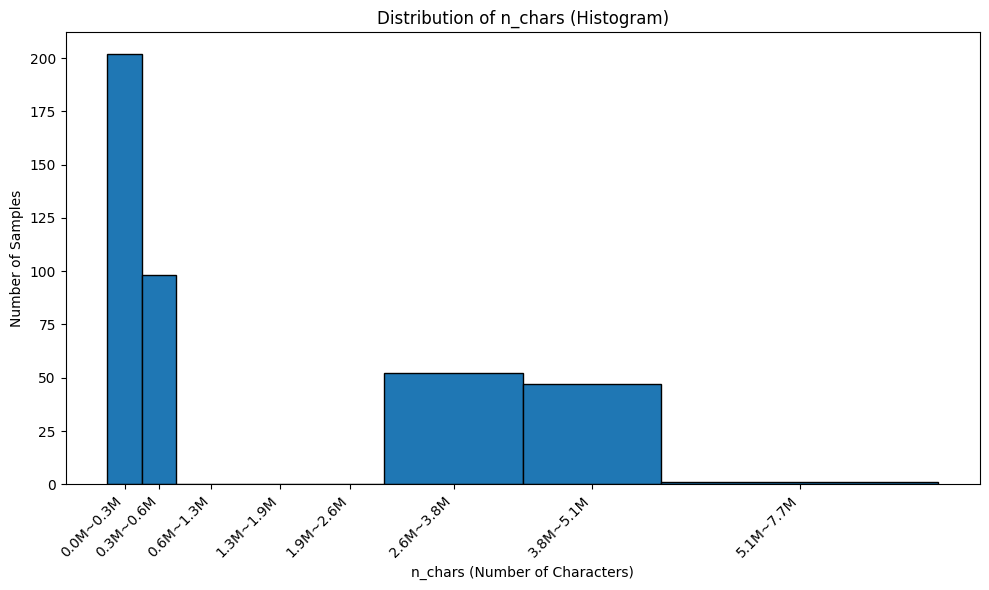

In [17]:
print(dataset_df.n_chars.describe())
import matplotlib.pyplot as plt
import numpy as np

custom_bins = [
    0, 64000 * 5, 128000 * 5, 256000 * 5, 384000 * 5, 512000 * 5, 768000 * 5, 1024000 * 5, 1536000 * 5,
]

# 计算每个bin的中点（作为刻度位置）
bin_centers = [(custom_bins[i] + custom_bins[i+1])/2 for i in range(len(custom_bins)-1)]

# 自定义标签文本（示例：显示区间范围）
bin_labels = [
    f"{custom_bins[i]/1e6:.1f}M~{custom_bins[i+1]/1e6:.1f}M" 
    for i in range(len(custom_bins)-1)
]

plt.figure(figsize=(10, 6))
dataset_df["n_chars"].plot(
    kind="hist",
    bins=custom_bins,
    edgecolor="black"
)

# 设置x轴刻度：位置=bin中点，标签=自定义文本
plt.xticks(
    ticks=bin_centers,  # 对齐柱子中心
    labels=bin_labels,  # 自定义标签
    rotation=45,
    ha="right"  # 标签右对齐，避免重叠
)

plt.title("Distribution of n_chars (Histogram)")
plt.xlabel("n_chars (Number of Characters)")
plt.ylabel("Number of Samples")
plt.tight_layout()  # 自动调整布局，防止标签被截断
plt.show()

In [4]:
with open('temp_old/thinking/138_512k_696605.txt', 'r') as f:
    token_length = len(tokenizer(f.read())["input_ids"])
    print(f'expert: token length: {token_length}, tokens per second: {token_length/153}')

with open('temp/thinking/138_512k_696605.txt', 'r') as f:
    token_length = len(tokenizer(f.read())["input_ids"])
    print(f'fast: token length: {token_length}, tokens per second: {token_length/46}')

expert: token length: 6525, tokens per second: 42.64705882352941
fast: token length: 2226, tokens per second: 48.391304347826086
